In [2]:
# ============================================================
# Neural Network From Scratch — Digits 0 vs 1 Use Case
# Binary handwritten-digit classification + prediction gallery
#
# External requirements:
#   - NumPy
#   - Matplotlib
#   - scikit-learn
#
# Shared NN components imported from nn-from-scratch:
#   - Dense
#   - Tanh
#   - Sigmoid
#   - Mean Squared Error
#   - Forward prediction
#   - Backpropagation training loop
#
# This notebook contains:
#   1. Shared NN path discovery
#   2. Neural-network component imports
#   3. Built-in Digits dataset loading
#   4. Digit 0 and digit 1 sample filtering
#   5. Invalid-value detection and removal
#   6. Pixel normalization from [0, 16] to [0, 1]
#   7. Stratified train/test split
#   8. 8×8 image flattening into 64 input features
#   9. NN-compatible tensor reshaping
#  10. Image-classification network construction
#  11. Model training
#  12. Sigmoid-score and class prediction
#  13. Test accuracy and confusion-matrix calculation
#  14. Confusion-matrix and prediction-gallery visualization
# ============================================================

In [3]:
# ============================================================
# Imports
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

In [4]:
# ============================================================
# Base Layer
# ============================================================


class Layer:
    """
    Base class for every neural-network layer.

    Each layer must implement:

    forward(input):
        Receives the input of the layer and returns its output.

    backward(output_gradient, learning_rate):
        Receives the gradient of the loss with respect to the layer's output,
        calculates the gradient with respect to the layer's input, and updates
        trainable parameters when the layer contains any.
    """

    def __init__(self):
        self.input = None
        self.output = None

    def forward(self, input):
        raise NotImplementedError(
            "Every layer must implement its own forward() method."
        )

    def backward(self, output_gradient, learning_rate):
        raise NotImplementedError(
            "Every layer must implement its own backward() method."
        )


# ============================================================
# Dense / Fully Connected Layer
# ============================================================


class Dense(Layer):
    """
    A fully connected neural-network layer.

    If the input has shape:

        (input_size, 1)

    and the layer contains output_size neurons, then:

        weights shape = (output_size, input_size)
        bias shape    = (output_size, 1)
        output shape  = (output_size, 1)

    Forward propagation:

        Y = W @ X + B

    Backpropagation:

        dE/dW = dE/dY @ X.T
        dE/dB = dE/dY
        dE/dX = W.T @ dE/dY
    """

    def __init__(self, input_size, output_size):
        super().__init__()

        self.input_size = input_size
        self.output_size = output_size

        # Randomly initialize the trainable parameters.
        #
        # weights:
        # Each row contains the weights of one neuron.
        #
        # bias:
        # Each output neuron receives one bias value.
        self.weights = np.random.randn(output_size, input_size)
        self.bias = np.random.randn(output_size, 1)

    def forward(self, input):
        """
        Calculate the output of the layer.

        Y = W @ X + B
        """

        self.input = input
        self.output = np.dot(self.weights, self.input) + self.bias
        return self.output

    def backward(self, output_gradient, learning_rate):
        """
        Perform backpropagation through the Dense layer.

        output_gradient represents:

            dE/dY

        where:
            E = loss/error
            Y = output of this layer
        """

        # Gradient of the loss with respect to the weights:
        #
        # dE/dW = dE/dY @ X.T
        weights_gradient = np.dot(output_gradient, self.input.T)

        # Gradient of the loss with respect to the input:
        #
        # dE/dX = W.T @ dE/dY
        #
        # This must be calculated before updating the weights so that
        # the gradient uses the same weights that were used during the
        # corresponding forward pass.
        input_gradient = np.dot(self.weights.T, output_gradient)

        # Gradient-descent parameter update:
        #
        # new_parameter =
        #     old_parameter - learning_rate * parameter_gradient
        self.weights -= learning_rate * weights_gradient
        self.bias -= learning_rate * output_gradient

        # Return the input gradient so that the previous layer can continue
        # the backpropagation process.
        return input_gradient


# ============================================================
# Generic Activation Layer
# ============================================================


class Activation(Layer):
    """
    Generic activation layer.

    An Activation object receives:

        function:
            The activation function f(x).

        function_derivative:
            The derivative f'(x).

    Forward propagation:

        Y = f(X)

    Backpropagation:

        dE/dX = dE/dY ⊙ f'(X)

    where ⊙ is element-wise multiplication.
    """

    def __init__(self, function, function_derivative):
        super().__init__()
        self.function = function
        self.function_derivative = function_derivative

    def forward(self, input):
        """Apply the activation function element by element."""

        self.input = input
        self.output = self.function(self.input)
        return self.output

    def backward(self, output_gradient, learning_rate):
        """
        Apply the chain rule:

            dE/dX = dE/dY ⊙ f'(X)

        Activation layers do not contain trainable parameters, so the
        learning_rate argument is accepted for API consistency but is
        not used.
        """

        input_gradient = np.multiply(
            output_gradient,
            self.function_derivative(self.input),
        )

        return input_gradient

In [5]:
# ============================================================
# Tanh Activation
# ============================================================


class Tanh(Activation):
    """
    Hyperbolic-tangent activation.

    Function:

        tanh(x)

    Derivative:

        1 - tanh(x)^2

    Output range:

        (-1, 1)
    """

    def __init__(self):
        def tanh(x):
            return np.tanh(x)

        def tanh_derivative(x):
            return 1 - np.tanh(x) ** 2

        super().__init__(
            function=tanh,
            function_derivative=tanh_derivative,
        )


# ============================================================
# Sigmoid Activation
# ============================================================


class Sigmoid(Activation):
    """
    Sigmoid activation.

    Function:

        sigmoid(x) = 1 / (1 + exp(-x))

    Derivative:

        sigmoid(x) * (1 - sigmoid(x))

    Output range:

        (0, 1)
    """

    def __init__(self):
        def sigmoid(x):
            return 1 / (1 + np.exp(-x))

        def sigmoid_derivative(x):
            sigmoid_output = sigmoid(x)
            return sigmoid_output * (1 - sigmoid_output)

        super().__init__(
            function=sigmoid,
            function_derivative=sigmoid_derivative,
        )


# ============================================================
# Loss Function — Mean Squared Error
# ============================================================


def mse(y_true, y_pred):
    """
    Mean Squared Error.

    Formula:

        MSE = mean((y_true - y_pred)^2)
    """

    return np.mean(np.power(y_true - y_pred, 2))


def mse_derivative(y_true, y_pred):
    """
    Derivative of Mean Squared Error with respect to y_pred.

    If:

        E = mean((y_true - y_pred)^2)

    then:

        dE/dy_pred = 2 * (y_pred - y_true) / number_of_values
    """

    return 2 * (y_pred - y_true) / np.size(y_true)


# Alias matching the name used by the separated implementation.
mse_prime = mse_derivative

In [6]:
# ============================================================
# Prediction / Forward Propagation
# ============================================================


def predict(network, input):
    """
    Pass an input through every layer in the network.

    The output of one layer becomes the input of the next layer.
    """

    output = input

    for layer in network:
        output = layer.forward(output)

    return output


# ============================================================
# Training
# ============================================================


def train(
    network,
    loss,
    loss_derivative,
    X_train,
    Y_train,
    epochs=10_000,
    learning_rate=0.01,
    verbose=True,
    print_every=10,
):
    """
    Train the neural network using sample-by-sample gradient descent.

    For every epoch:

        1. Send every training sample through the network.
        2. Calculate its loss.
        3. Calculate the derivative of the loss.
        4. Send the gradient backward through all layers.
        5. Update the trainable parameters.
        6. Calculate the average epoch loss.

    Returns:
        A NumPy array containing the average loss from every epoch.
    """

    loss_history = []

    for epoch in range(epochs):
        epoch_error = 0.0

        for x, y in zip(X_train, Y_train):

            # ------------------------------------------------
            # Forward propagation
            # ------------------------------------------------

            output = predict(network, x)

            # ------------------------------------------------
            # Calculate loss
            # ------------------------------------------------

            epoch_error += loss(y, output)

            # ------------------------------------------------
            # Initial loss gradient
            # ------------------------------------------------

            gradient = loss_derivative(y, output)

            # ------------------------------------------------
            # Backpropagation
            # ------------------------------------------------
            #
            # Gradients must flow in the reverse order:
            #
            # output layer -> ... -> input layer
            # ------------------------------------------------

            for layer in reversed(network):
                gradient = layer.backward(gradient, learning_rate)

        # Average error across the training samples.
        epoch_error /= len(X_train)
        loss_history.append(epoch_error)

        if (
            verbose
            and print_every is not None
            and epoch % print_every == 0
        ):
            print(
                f"Epoch {epoch + 1:4d}/{epochs}, "
                f"loss={epoch_error:.10f}"
            )

    return np.array(loss_history)

Epoch    1/180, loss=0.1654050538
Epoch   11/180, loss=0.0008380443
Epoch   21/180, loss=0.0003334464
Epoch   31/180, loss=0.0002130470
Epoch   41/180, loss=0.0001564249
Epoch   51/180, loss=0.0001230016
Epoch   61/180, loss=0.0001008082
Epoch   71/180, loss=0.0000849716
Epoch   81/180, loss=0.0000731113
Epoch   91/180, loss=0.0000639160
Epoch  101/180, loss=0.0000565984
Epoch  111/180, loss=0.0000506546
Epoch  121/180, loss=0.0000457455
Epoch  131/180, loss=0.0000416340
Epoch  141/180, loss=0.0000381491
Epoch  151/180, loss=0.0000351643
Epoch  161/180, loss=0.0000325843
Epoch  171/180, loss=0.0000303355
Digits 0 vs 1 test accuracy: 97.78%


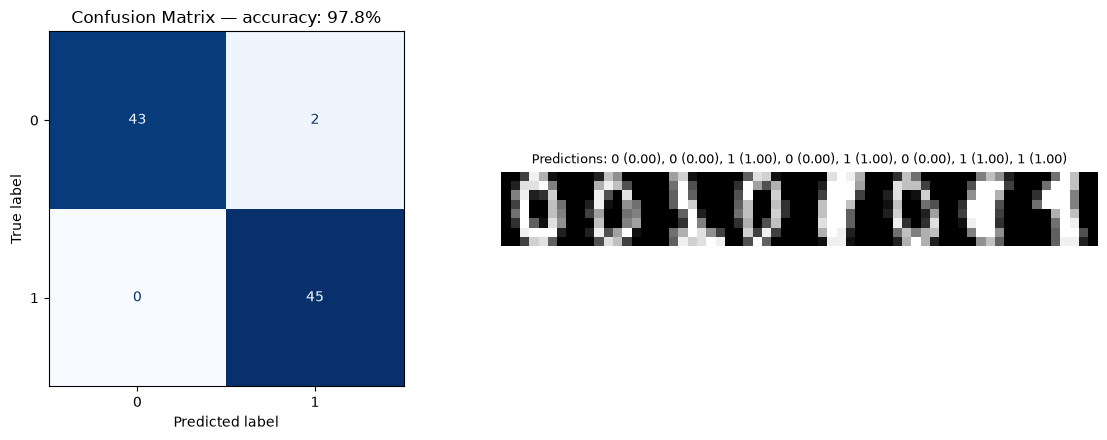

In [7]:
from sklearn.datasets import load_digits
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split

# load_digits is bundled with scikit-learn; it requires no manual download.
digits_data = load_digits()
binary_mask = np.isin(digits_data.target, [0, 1])
X = digits_data.data[binary_mask].astype(float)
y = digits_data.target[binary_mask].astype(int)
images = digits_data.images[binary_mask]

valid_rows = np.isfinite(X).all(axis=1) & np.isfinite(y)
X, y, images = X[valid_rows], y[valid_rows], images[valid_rows]

# Pixel values in this dataset range from 0 to 16.
X = X / 16.0

indices = np.arange(len(X))
train_indices, test_indices = train_test_split(
    indices,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

X_train, X_test = X[train_indices], X[test_indices]
y_train, y_test = y[train_indices], y[test_indices]
test_images = images[test_indices]

X_train_nn = X_train[:, :, np.newaxis]
X_test_nn = X_test[:, :, np.newaxis]
y_train_nn = y_train.reshape(-1, 1, 1)

network = [
    Dense(64, 32),
    Tanh(),
    Dense(32, 16),
    Tanh(),
    Dense(16, 1),
    Sigmoid(),
]

train(
    network,
    mse,
    mse_prime,
    X_train_nn,
    y_train_nn,
    epochs=180,
    learning_rate=0.03,
    verbose=True,
)

test_scores = np.array(
    [float(predict(network, x)[0, 0]) for x in X_test_nn]
)
test_predictions = (test_scores >= 0.5).astype(int)
test_accuracy = np.mean(test_predictions == y_test)

print(f"Digits 0 vs 1 test accuracy: {test_accuracy:.2%}")

matrix = confusion_matrix(y_test, test_predictions, labels=[0, 1])
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=["0", "1"],
).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"Confusion Matrix — accuracy: {test_accuracy:.1%}")

# Show several test images together with the model's prediction confidence.
axes[1].axis("off")
sample_count = min(8, len(test_images))
gallery = np.concatenate(test_images[:sample_count], axis=1)
axes[1].imshow(gallery, cmap="gray")
axes[1].set_title(
    "Predictions: "
    + ", ".join(
        f"{prediction} ({score:.2f})"
        for prediction, score in zip(
            test_predictions[:sample_count],
            test_scores[:sample_count],
        )
    ),
    fontsize=9,
)

plt.tight_layout()
plt.show()
